In [9]:
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv("board2.csv") #Loads the file
df

,Name,Gender,Track,Hometown,Math,Electronics,GEAS,Communication
0,S1,Male,Instrumentation,Luzon,58,89,75,78
1,S2,Female,Communication,Mindanao,52,75,90,52
2,S3,Female,Instrumentation,Mindanao,83,74,77,57
3,S4,Male,Instrumentation,Visayas,65,58,91,68
4,S5,Male,Communication,Luzon,59,86,43,88
5,S6,Female,Microelectronics,Visayas,88,45,86,83
6,S7,Female,Instrumentation,Luzon,66,60,60,48
7,S8,Male,Instrumentation,Luzon,49,81,64,53
8,S9,Male,Instrumentation,Luzon,50,36,63,42
9,S10,Male,Microelectronics,Mindanao,80,84,61,44


In [11]:
df.columns = ['Name', 'Gender', 'Track', 'Hometown',
              'Math', 'GEAS', 'Electronics', 'Average']
df.columns.tolist()

['Name',
 'Gender',
 'Track',
 'Hometown',
 'Math',
 'GEAS',
 'Electronics',
 'Average']

### A:

In [13]:
VisComm = df[(df["Hometown"] == "Visayas") & (df["Track"] == "Communication")][
    ["Name", "Gender", "Math", "Electronics", "Average"] #Displaying specific columns
]
VisComm

,Name,Gender,Math,Electronics,Average
10,S11,Female,48,48,67
11,S12,Male,89,84,64
17,S18,Male,81,81,52
21,S22,Female,64,89,58
27,S28,Male,85,80,53


In [20]:
print("Number of rows in VisComm:", {len(VisComm)})

Number of rows in VisComm: {5}


### B:

In [24]:
VisFemale = df[(df["Hometown"] == "Visayas") & (df["Gender"] == "Female")][
    ["Name", "Track", "GEAS", "Electronics", "Average"]
]

VisFemale

,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,45,86,83
10,S11,Communication,56,48,67
20,S21,Microelectronics,51,68,72
21,S22,Communication,39,89,58
23,S24,Microelectronics,45,60,41
25,S26,Instrumentation,47,83,62


In [25]:
# Display only rows of VisFemale whose Average >= 60
VisFemale_high_avg = VisFemale[VisFemale["Average"] >= 60]

VisFemale_high_avg


,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,45,86,83
10,S11,Communication,56,48,67
20,S21,Microelectronics,51,68,72
25,S26,Instrumentation,47,83,62


### C:

In [31]:

#Compute mean of Average for every category in Track, Gender, Hometown
track_means = df.groupby("Track")["Average"].mean()
gender_means = df.groupby("Gender")["Average"].mean()
hometown_means = df.groupby("Hometown")["Average"].mean()

display(track_means)
display(gender_means)
display(hometown_means)

Track
Communication       64.2
Instrumentation     57.3
Microelectronics    64.4
Name: Average, dtype: float64

Gender
Female    63.533333
Male      60.400000
Name: Average, dtype: float64

Hometown
Luzon       60.166667
Mindanao    61.571429
Visayas     64.181818
Name: Average, dtype: float64

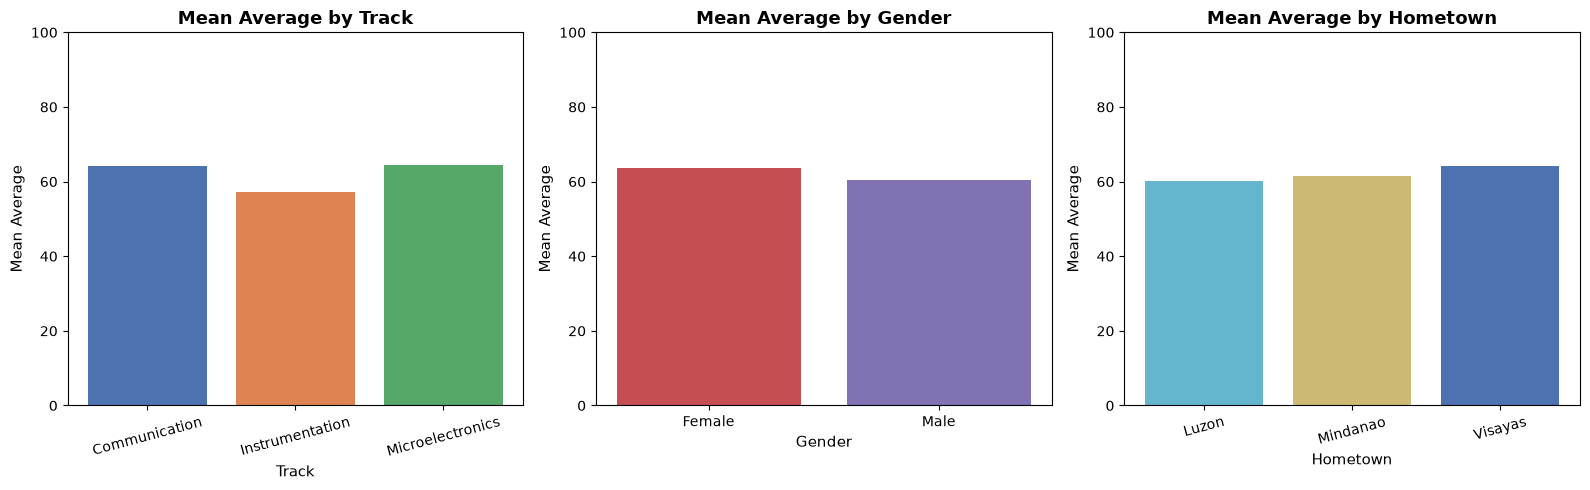

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

#Mean Average by Track ---
axes[0].bar(track_means.index, track_means.values, color=["#4C72B0", "#DD8452", "#55A868"])
axes[0].set_title("Mean Average by Track", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Track", fontsize=11)
axes[0].set_ylabel("Mean Average", fontsize=11)
axes[0].tick_params(axis="x", rotation=15)
axes[0].set_ylim(0, 100)  # Consistent scale (board exam scores are 0–100)

#Mean Average by Gender ---
axes[1].bar(gender_means.index, gender_means.values, color=["#C44E52", "#8172B3"])
axes[1].set_title("Mean Average by Gender", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Gender", fontsize=11)
axes[1].set_ylabel("Mean Average", fontsize=11)
axes[1].set_ylim(0, 100)

#Mean Average by Hometown ---
axes[2].bar(hometown_means.index, hometown_means.values, color=["#64B5CD", "#CCB974", "#4C72B0"])
axes[2].set_title("Mean Average by Hometown", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Hometown", fontsize=11)
axes[2].set_ylabel("Mean Average", fontsize=11)
axes[2].tick_params(axis="x", rotation=15)
axes[2].set_ylim(0, 100)


plt.tight_layout()
plt.show()

In [32]:

print(f"Track: '{track_means.idxmax()}' has the highest sample mean Average "
      f"({track_means.max():.2f}).")
print(f"Gender: '{gender_means.idxmax()}' has the highest sample mean Average "
      f"({gender_means.max():.2f}).")
print(f"Hometown: '{hometown_means.idxmax()}' has the highest sample mean Average "
      f"({hometown_means.max():.2f}).")

Track: 'Microelectronics' has the highest sample mean Average (64.40).
Gender: 'Female' has the highest sample mean Average (63.53).
Hometown: 'Visayas' has the highest sample mean Average (64.18).
